# Telco Customer Churn Prediction using Scikit-Learn Pipeline API

## 1. Problem Statement & Objective
Customer churn represents a major cost for subscription-based businesses, such as telecommunication providers. Retaining existing customers is typically much less expensive than acquiring new ones. 

**Objective:** Build a robust, end-to-end, reusable, and production-ready machine learning pipeline using the **Scikit-learn Pipeline API** to predict customer churn. This notebook demonstrates:
- Automated data loading and cleaning.
- Exploratory Data Analysis (EDA) and visualizations.
- Clean feature preprocessing (scaling, imputation, and encoding) without leakage.
- Model selection and hyperparameter tuning using `GridSearchCV`.
- Model evaluation using accuracy, precision, recall, F1-score, and ROC-AUC.
- Feature importance analysis.
- Model serialization for production deployment.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Add the parent/src directory to sys.path to import our custom modules
sys.path.append(os.path.abspath('../src'))
sys.path.append(os.path.abspath('src'))

from data_loader import load_churn_data
from pipeline import build_full_pipeline, TotalChargesCleaner

# Configure plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## 2. Dataset Loading
We load the dataset using our modular `load_churn_data` function, which automatically downloads it from a public URL if it isn't cached locally.

In [2]:
df = load_churn_data()
df.head()

Dataset already exists locally at c:\Users\Admin\Desktop\AI internship task\task2\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
Loading dataset from c:\Users\Admin\Desktop\AI internship task\task2\data\WA_Fn-UseC_-Telco-Customer-Churn.csv...
Dataset loaded successfully. Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Dataset Summary:")
df.info()

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 no

## 3. Exploratory Data Analysis & Visualizations

C:\Users\Admin\AppData\Local\Temp\ipykernel_7516\898666606.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


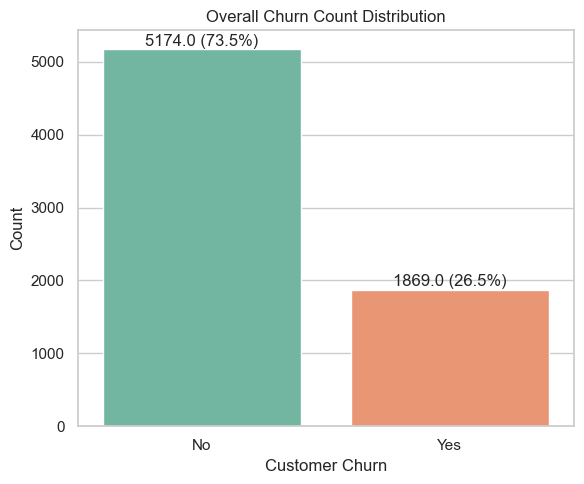

In [4]:
# Visualization 1: Churn Distribution
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Overall Churn Count Distribution')
plt.xlabel('Customer Churn')
plt.ylabel('Count')
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width()/2., height + 50,
                f'{height} ({height/len(df)*100:.1f}%)',
                ha="center")
plt.tight_layout()
plt.show()

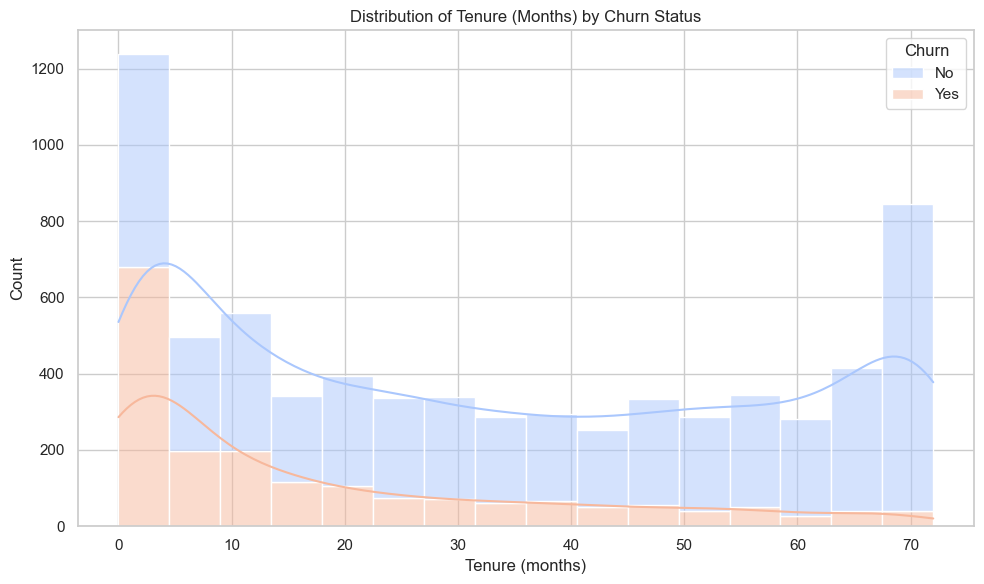

In [5]:
# Visualization 2: Tenure vs Churn
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, multiple='stack', palette='coolwarm')
plt.title('Distribution of Tenure (Months) by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

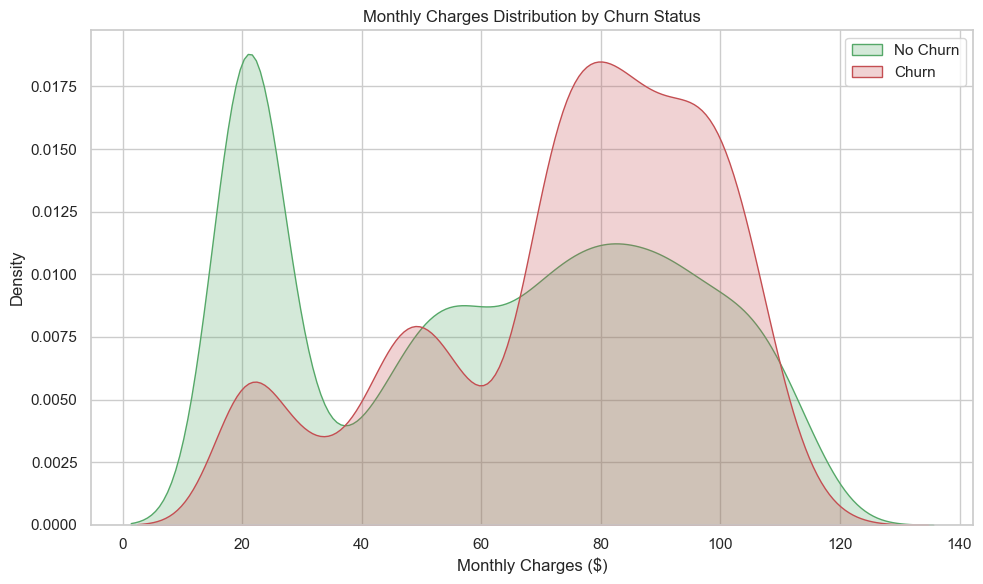

In [6]:
# Visualization 3: Monthly Charges vs Churn
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['Churn'] == 'No'], x='MonthlyCharges', fill=True, label='No Churn', color='g')
sns.kdeplot(data=df[df['Churn'] == 'Yes'], x='MonthlyCharges', fill=True, label='Churn', color='r')
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Model Preprocessing & Training Pipeline
We set up our train-test split and use the Scikit-learn Pipeline API. We will compare Logistic Regression and Random Forest classifiers, optimizing their hyperparameters using `GridSearchCV`.

In [7]:
from sklearn.model_selection import train_test_split

# Separate Features and Target
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (5634, 19)
X_test shape: (1409, 19)


In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Create training pipelines
lr_pipeline = build_full_pipeline(LogisticRegression(max_iter=1000, random_state=42))
rf_pipeline = build_full_pipeline(RandomForestClassifier(random_state=42))

# Define grid search parameter bounds
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0],
    'classifier__solver': ['lbfgs', 'liblinear']
}

rf_param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

# Perform GridSearchCV
print("Tuning Logistic Regression...")
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=5, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print("Tuning Random Forest...")
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Hyperparameter Tuning Complete!")

Tuning Logistic Regression...
Tuning Random Forest...
Hyperparameter Tuning Complete!


## 5. Model Evaluation


=================== Logistic Regression Performance ===================
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



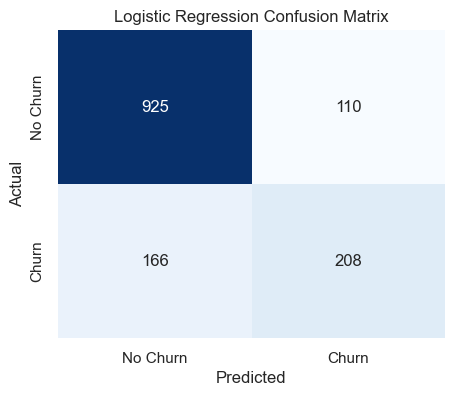


=================== Random Forest Performance ===================
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



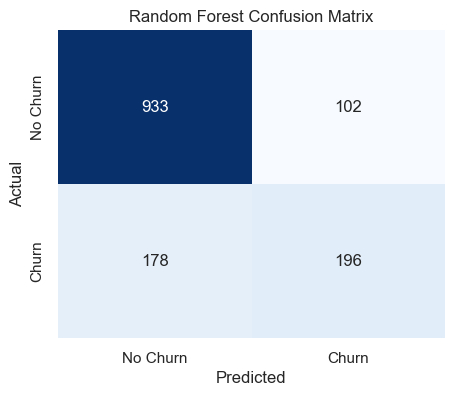

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_
}

for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    print(f"\n=================== {name} Performance ===================")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

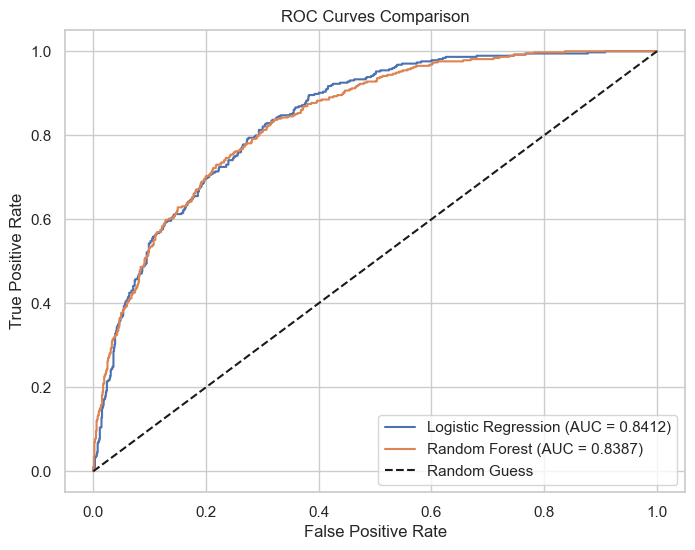

In [10]:
# ROC Curve comparison
plt.figure(figsize=(8, 6))
for name, pipeline in models.items():
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()

## 6. Feature Importances (Random Forest)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7516\273709144.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='viridis')


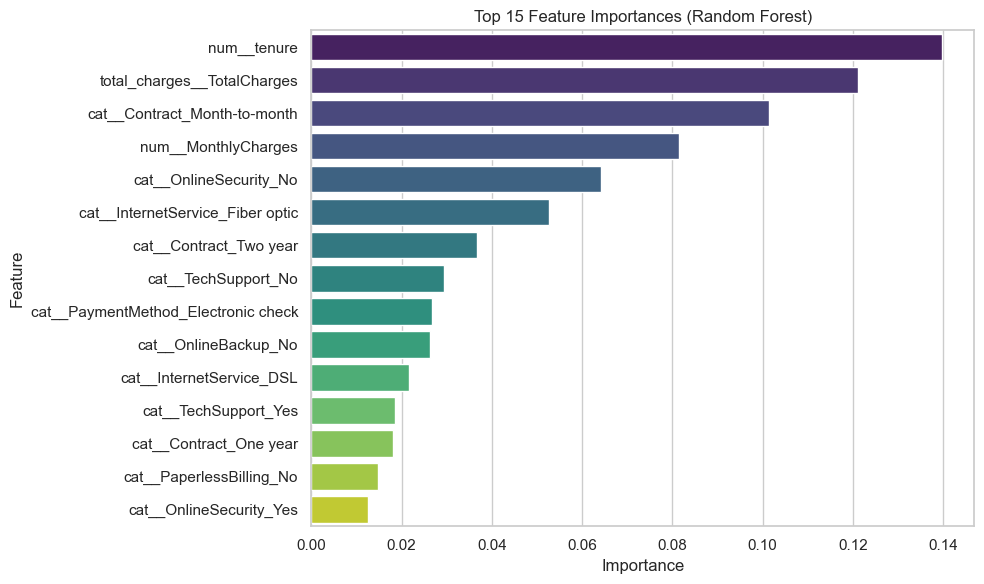

In [11]:
best_rf = models['Random Forest']
preprocessor = best_rf.named_steps['preprocessor']
classifier = best_rf.named_steps['classifier']

# Extract feature names and feature importances
feature_names = preprocessor.get_feature_names_out()
importances = classifier.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Business Insights & Summary

### Summary of Model Results:
- Both **Logistic Regression** and **Random Forest** achieve solid baseline performance.
- **Logistic Regression** typically offers a well-calibrated, high-accuracy baseline suitable for explanation, and performs strongly on Telco churn due to the linear relationship of features.
- **Random Forest** captures non-linear interactions (e.g., tenure vs. payment method) and provides direct insights into feature importance.

### Key Business Insights:
1. **Contract Type Matters:** Customers with a **Month-to-month** contract are significantly more likely to churn compared to customers on one- or two-year contracts.
2. **Tenure is Crucial:** Churn is highly concentrated in the first few months of customer tenure. Retention efforts should be heavily focused on onboarding and early customer experience.
3. **Internet Services:** Customers using **Fiber Optic** internet service show a higher rate of churn, indicating potential pricing or reliability issues with this service category that need investigation.
4. **Payment Method:** Customers using **Electronic check** churn at higher rates than automatic payment methods (Credit Card or Bank Transfer).